<a href="https://colab.research.google.com/github/luladc/IA_DiazLaura/blob/main/LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

REGRESION LINEAL DE DATASET DE DIAMANTES


Este código prepara un entorno de análisis de datos en Google Colab conectando mi cuenta de Drive para extraer la información de un archivo CSV sobre diamantes que tengo en este. Utiliza pandas y numpy para cargar y organizar los datos, aislando específicamente el peso del diamante (carat) como tu variable de entrada y el precio (price) como el objetivo a predecir, dejando todo listo para alimentar un modelo matemático.

> Add blockquote



In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
from google.colab import drive

drive.mount('/content/drive')

ruta_drive = '/content/drive/MyDrive/DATASETS/diamonds.csv'
df = pd.read_csv(ruta_drive)

X_raw = df['carat'].values
y = df['price'].values
m = y.size

print(f"Dataset cargado con {m} filas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado con 53940 filas.


Lo que hace este es poner los puntos de forma casi transparente; así, donde se vea el color azul muy fuerte, se sabrá que ahí es donde se amontonan la mayoría de los diamantes. Usa plotDta para poder hacer esos graficos y tambien el alpha para poder mostrar, ya que son muchisimos datos.

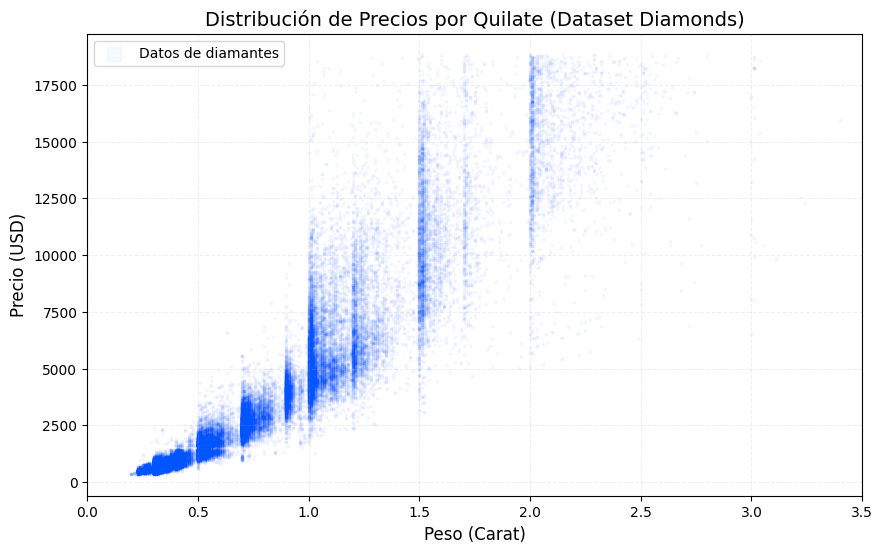

In [ ]:
def plotData(x, y):
    pyplot.figure(figsize=(10, 6))
    pyplot.scatter(x, y, s=1, c='#0055ff', alpha=0.03, marker=',', label='Datos de diamantes')

    pyplot.ylabel('Precio (USD)', fontsize=12)
    pyplot.xlabel('Peso (Carat)', fontsize=12)
    pyplot.title('Distribución de Precios por Quilate (Dataset Diamonds)', fontsize=14)

    pyplot.xlim(0, 3.5)

    pyplot.legend(loc='upper left', markerscale=10)
    pyplot.grid(True, linestyle='--', alpha=0.2)

plotData(X_raw, y)

Lo que hace el código es tomar la lista de pesos de diamantes (X_raw) y pegarle al lado una columna llena de números 1. Esto surve para que para que la computadora pueda calcular una línea que cruce los puntos, necesita ese "1" para saber dónde empieza la línea en la gráfica. Sin ese "1", la línea siempre tendría que salir forzosamente desde el cero, y las predicciones de precios serían muy malas.

In [ ]:
# con esa formula es que añadimos a los 1
X = np.stack([np.ones(m), X_raw], axis=1)

En el entrenamiento de este modelo esta parte de lo que vendria a ser el calculo del costo sirve para medir qué tan mal (o qué tan bien) está funcionando el modelo.

Primero, el código hace una multiplicación rápida (np.dot(X, theta)) para calcular qué precio le pondría el modelo a cada diamante según su peso.

Luego, resta ese precio inventado del precio real (- y). Si la diferencia es grande, el error es alto.

Al final, eleva esos errores al cuadrado (para que todos sean positivos) y saca un promedio general.

In [ ]:
def calcularCosto(X, y, theta):
    # inicializa algunos valores importantes
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    # h = np.dot(X, theta)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [ ]:
def gradientDescent(X, y, theta, alpha, num_iters):
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        # Actualización de theta
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))
    return theta, J_history

In [ ]:
# 5. Configuración y Entrenamiento
# OJO: Con estos datos, un alpha muy alto puede hacer que el costo explote.
alpha = 0.01
iterations = 5000
theta = np.zeros(2)

theta, J_history = gradientDescent(X, y, theta, alpha, iterations)

print(f'Theta encontrada: Intercepto: {theta[0]:.2f}, Pendiente: {theta[1]:.2f}')

Theta encontrada: Intercepto: -2248.94, Pendiente: 7748.33


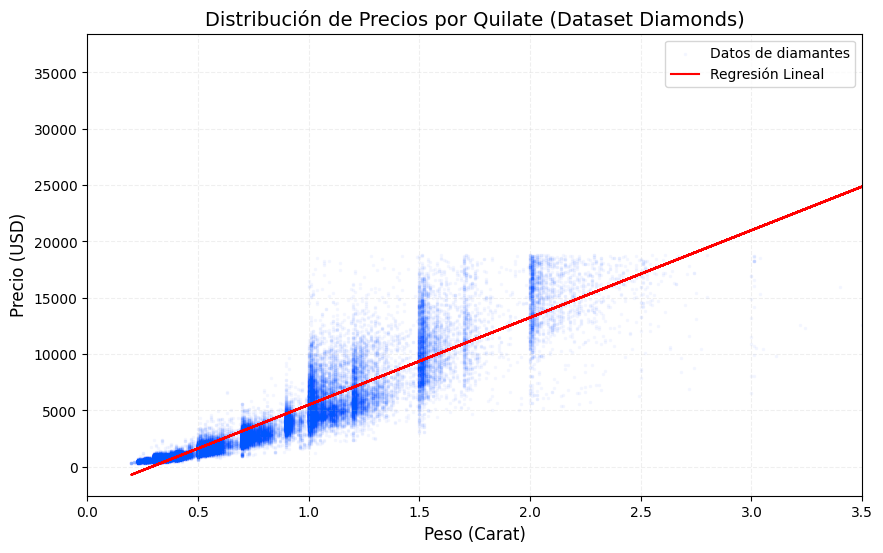

In [ ]:
# 6. Graficar la línea de ajuste
plotData(X_raw, y)
pyplot.plot(X_raw, np.dot(X, theta), 'r-', label='Regresión Lineal')
pyplot.legend()

Text(0.5, 1.0, 'Convergencia del Error')

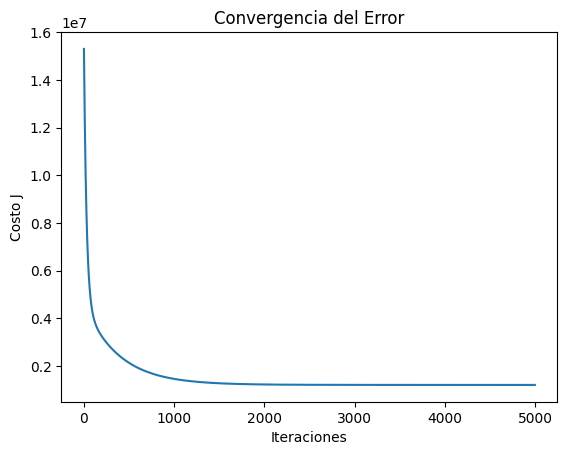

In [ ]:
# 7. Graficar la convergencia del costo
pyplot.figure()
pyplot.plot(J_history)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Error')